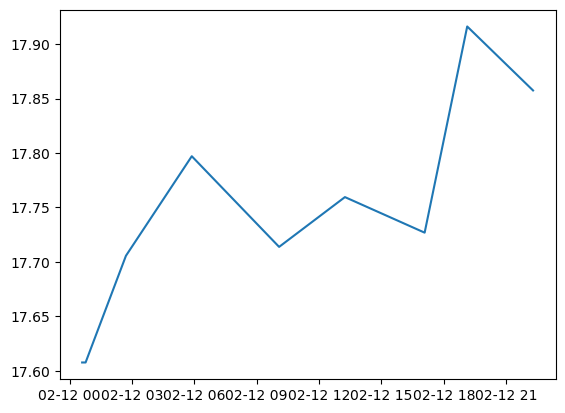

In [5]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score as mlr_r2_score

import glide.science_data_processing.L1A as L1A 

with xr.open_dataset('/carrdata/L1A/CARRUTHERS_GCI-WFI_L1A-DRK_20260212_v1.0.nc', engine='netcdf4') as data:
    l1a_obj = L1A.L1A(data)
    fw_temp = data['fw_temp'].values


plt.plot(l1a_obj.time, fw_temp )

Skipping trend line for 2025-10: No training data in 2025-09


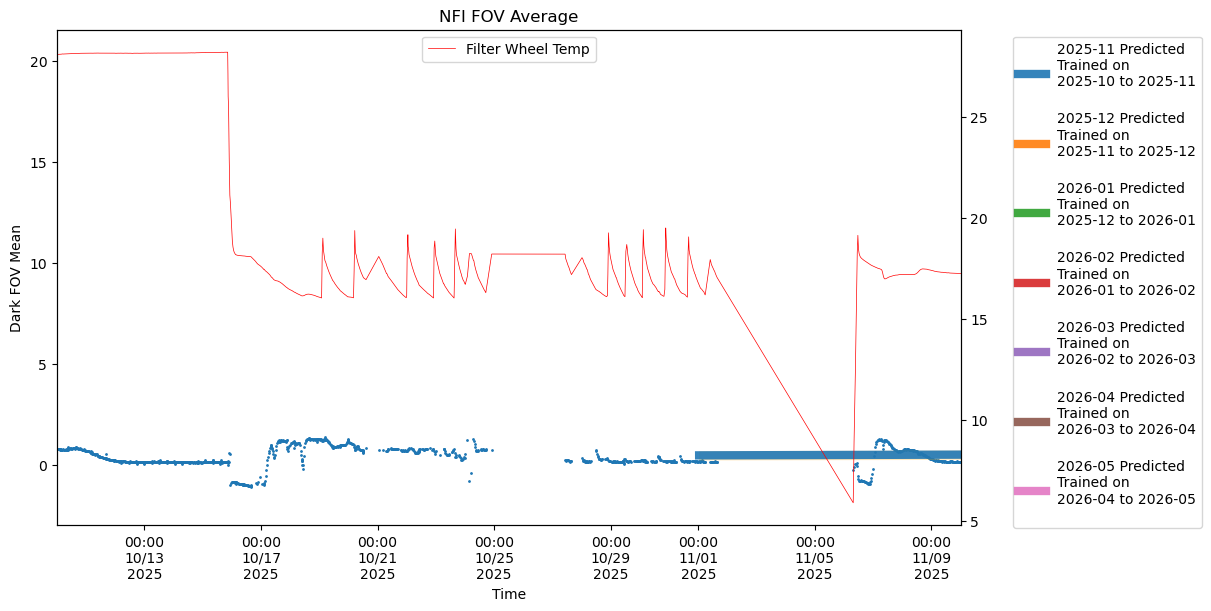

In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score as mlr_r2_score

ds = xr.open_dataset('products/NFI_FOV_AVG.nc')

fig, ax = plt.subplots(1, 1, figsize=(12, 6), layout='constrained')
full_fov_mean = ( ds["fov_mean_top"].values + ds["fov_mean_bottom"].values) /2
time = ds["time"].values
fw_temp = ds['fw_temp'].values



ax.scatter(time, full_fov_mean, s=1)
ax.set_xlabel("Time")
ax.set_ylabel("Dark FOV Mean (DN/sec-pix)")
ax.set_title("NFI FOV Average")
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M\n%m/%d\n%Y'))


# Build DataFrame
df = pd.DataFrame({
    'fov_mean': full_fov_mean,
    'time': pd.to_datetime(time)
})

# Calculate a single baseline for time_numeric across the entire dataset
df['time_numeric'] = (df['time'] - df['time'].min()).dt.total_seconds()

# Create a 'month' tracking column (e.g., '2026-01', '2026-02')
df['month'] = df['time'].dt.to_period('M')

models = {}


# Automatically loop through every unique month found in your data
for month, group in df.groupby('month'):

    # Identify the previous month period
    prev_month = month - 1
    
    # 2. Extract training data from the previous month
    train_data = df[df['month'] == prev_month]
    
    # Ensure the previous month actually has data to fit a line
    if len(train_data) < 2:
        print(f"Skipping trend line for {month}: No training data in {prev_month}")
        continue
    # Ensure there are enough data points to fit a line
    if len(group) < 2:
        continue
        
    X_train = train_data[['time_numeric']]
    y_train = train_data['fov_mean']
    X_current = group[['time_numeric']]

    # Train the model on this specific month chunk
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_current)
    
    # Plot the trend line over the exact timestamps of this month chunk
    # Using group['time'].dt.to_pydatetime() avoids matplotlib formatting issues

    linew = 6
    err = 0.2

    ax.plot(group['time'], y_pred, label=f'{month} Predicted\nTrained on \n{prev_month} to {month}\n', linewidth=linew, alpha=0.9)
    ax.fill_between(group['time'], y_pred - err, y_pred + err, color='orange', alpha=0.2, label='_nolegend_')

    
    # Save the model object into your dictionary using the month string as the key
    models[str(month)] = model


ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')



ax1 = plt.twinx(ax)
ax1.plot(time, fw_temp, label='Filter Wheel Temp', c='r', lw=0.5)
ax1.legend(loc='upper center')
ax1.set_ylabel("Dark FOV Mean")


ax.set_xlim(np.datetime64('2025-10-10'), np.datetime64('2025-11-10'))
#ax.set_ylim(0, 0.6)
















plt.show()

<xarray.DataArray 'time' ()> Size: 8B
[1 values with dtype=datetime64[ns]]
Coordinates:
    observation  datetime64[ns] 8B 2026-01-27T22:41:05


Locator attempting to generate 5395 ticks ([20365.166666666668, ..., 20589.916666666668]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 5395 ticks ([20365.166666666668, ..., 20589.916666666668]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 5395 ticks ([20365.166666666668, ..., 20589.916666666668]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 5395 ticks ([20365.166666666668, ..., 20589.916666666668]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 5395 ticks ([20365.166666666668, ..., 20589.916666666668]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 5395 ticks ([20365.166666666668, ..., 20589.916666666668]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 5395 ticks ([20365.166666666668, ..., 20589.916666666668]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 5395 ticks ([20365.166666666668, ..., 20589.916666666668]),

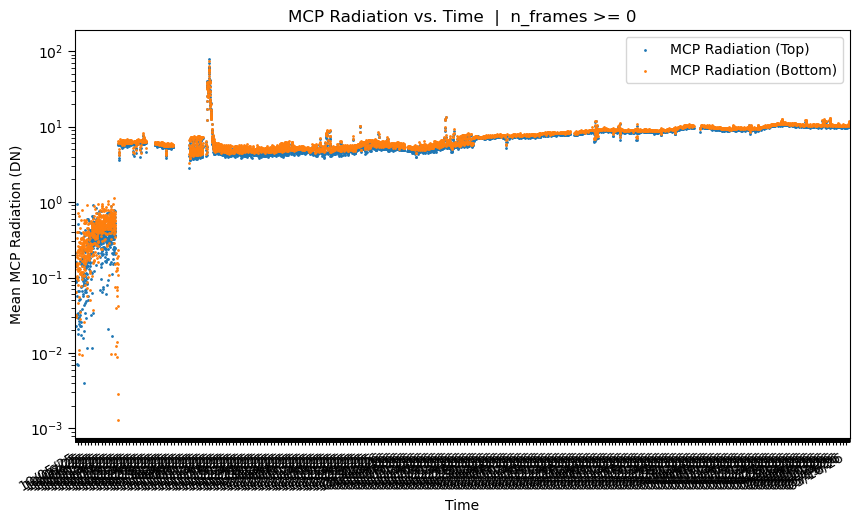

In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

from plotting import plot_data_vs_time
from avg import filter_time_range
from avg import filter_n_frames

ds = xr.open_dataset('products/WFI_FOV_AVG.nc')
mcp_rad_top = ds["fov_mean_top"].values
mcp_rad_bottom = ds["fov_mean_bottom"].values
print(ds["time"][3074])
start_datetime_str = '2024-10-05T00:00:00.000000'
end_datetime_str = '2026-10-16T00:00:00.000000'

# Convert the strings to datetime objects
start_datetime = np.datetime64(start_datetime_str)
end_datetime = np.datetime64(end_datetime_str)

n_frames_min = 0

mcp_rad_top = ds["fov_mean_top"].values
mcp_rad_bottom = ds["fov_mean_bottom"].values
datetimes = ds["time"].values
n_frames = ds["n_frames"].values
ds.close()

datetimes = datetimes.astype('datetime64[ns]')

# Filter data by time range
mcp_rad_top = filter_time_range(mcp_rad_top, datetimes, start_datetime, end_datetime)
mcp_rad_bottom = filter_time_range(mcp_rad_bottom, datetimes, start_datetime, end_datetime)
n_frames = filter_time_range(n_frames, datetimes, start_datetime, end_datetime)
datetimes = filter_time_range(datetimes, datetimes, start_datetime, end_datetime)

# Filter data by n_frames
mcp_rad_top = filter_n_frames(mcp_rad_top, n_frames, n_frames_min)
mcp_rad_bottom = filter_n_frames(mcp_rad_bottom, n_frames, n_frames_min)
datetimes_filtered = filter_n_frames(datetimes, n_frames, n_frames_min)


plot_data_vs_time(mcp_rad_top, mcp_rad_bottom, datetimes_filtered, n_frames_min, log=True)

plt.show()


In [4]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import os
from matplotlib.ticker import MultipleLocator

median_top_meds = np.load('products/column_bias_top_v2.npy')
median_bottom_meds = np.load('products/column_bias_bottom_v2.npy')

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(range(len(median_top_meds)), median_top_meds, s=1, alpha=1, label='Top Half Biases')
ax.scatter(range(len(median_bottom_meds)), median_bottom_meds, s=1, alpha=1, label='Bottom Half Biases')

ax.axhline(np.median(median_top_meds),
           color='blue',
           alpha=0.5,
           label=f'Median of Top Half Biases ({round(np.median(median_top_meds), 4)})')
ax.axhline(np.median(median_bottom_meds),
           color='orange',
           alpha=0.5,
           label=f'Median of Bottom Half Biases ({round(np.median(median_bottom_meds), 4)})')

ax.set_title('Column Voltage Biases, Top and Bottom Sensor Halves\n2025-10-04T00 to 2025-10-16T00\nWFI L1A-DRK Imagery')
ax.set_xlabel('Image Column')
ax.xaxis.set_major_locator(MultipleLocator(32))
ax.set_ylabel('Median Voltage Bias (DN n_frames$^{-1}$)')
ax.set_ylim(bottom=-2)

ax.legend(loc='lower center')
plt.show

FileNotFoundError: [Errno 2] No such file or directory: 'products/column_bias_top_v2.npy'

In [ ]:
import xarray as xr
ds = xr.open_dataset("data/WFI_1A-DRK/CARRUTHERS_GCI-WFI_L1A-DRK_20251112_v1.0.nc")

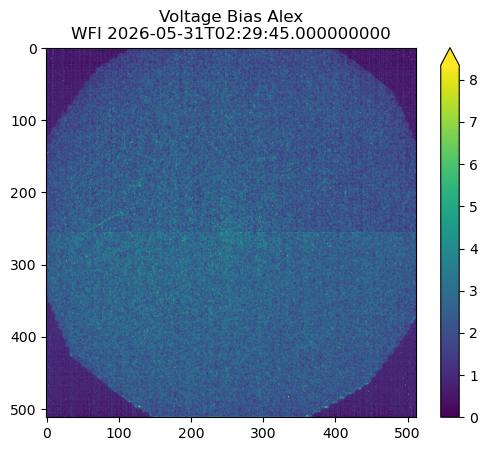

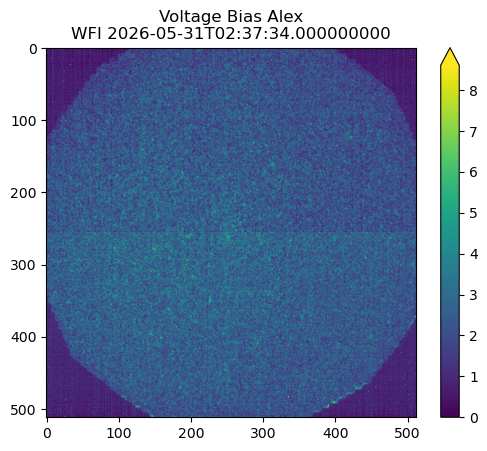

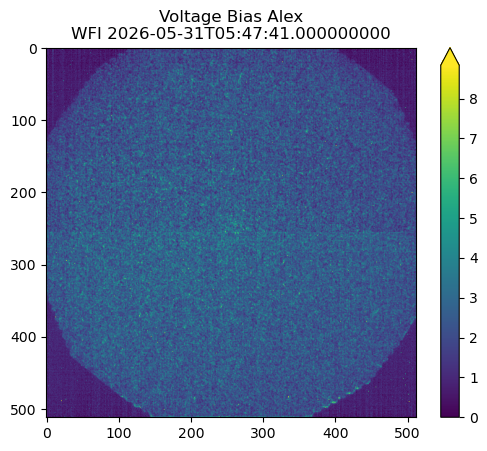

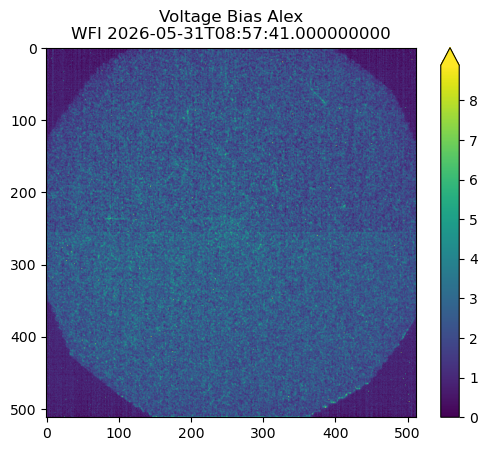

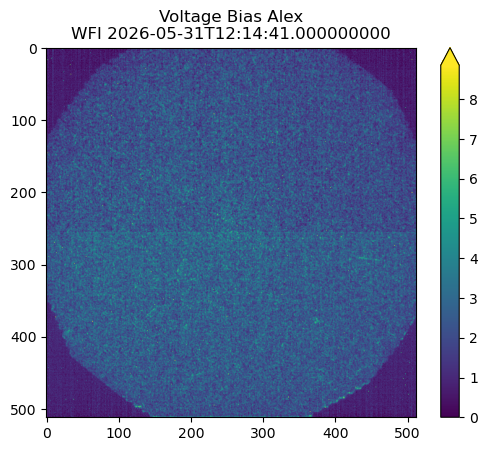

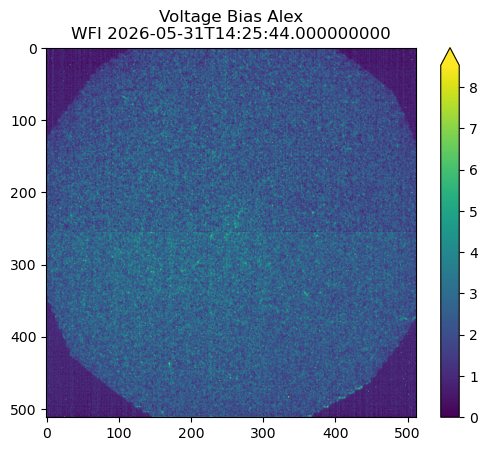

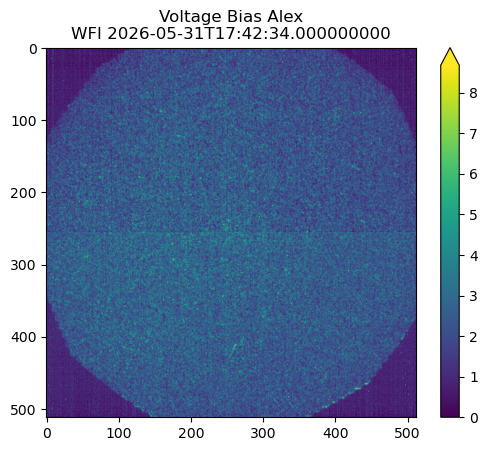

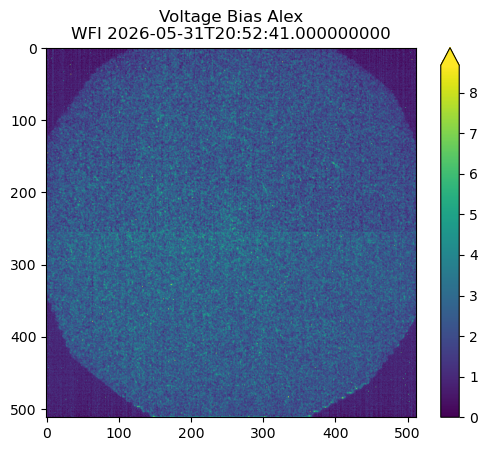

In [1]:
# VOLTAGE BIAS STRIPES REMOVAL DEMO

import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import glide.common_components.constants as constants
import glide.science_data_processing.L1A as L1A
from glide.calibration.bias_wavelet import wavelet_destripe
from glide.calibration.bias_wavelet import remove_dark_stripes
from scipy.interpolate import griddata
import cv2


def interpolate_nan_stack(stack):
    # Create an empty array with the same shape to store results
    filled_stack = np.copy(stack)
    
    # Generate static 2D grid coordinates for Y and X dimensions
    ny, nx = stack.shape[1], stack.shape[2]
    y_coords, x_coords = np.mgrid[0:ny, 0:nx]
    
    # Loop through each image slice along the Z axis
    for i in range(stack.shape[0]):
        slice_2d = stack[i, :, :]
        
        # Locate indices of NaN values and valid values
        nan_mask = np.isnan(slice_2d)
        
        # Skip slice if there are no NaNs to fix
        if not np.any(nan_mask):
            continue
            
        valid_mask = ~nan_mask
        
        # Get coordinates where data is valid (points) and their values
        points = np.column_stack((y_coords[valid_mask], x_coords[valid_mask]))
        values = slice_2d[valid_mask]
        
        # Get coordinates where data needs to be filled
        xi = np.column_stack((y_coords[nan_mask], x_coords[nan_mask]))
        
        # Perform 2D linear interpolation
        interpolated_values = griddata(points, values, xi, method='linear')
        
        # Insert interpolated values back into the slice copy
        filled_stack[i, nan_mask] = interpolated_values
        
    return filled_stack

def opencv_fill(stack):
    filled_stack = np.copy(stack)
    
    for i in range(stack.shape[0]):
        slice_2d = stack[i, :, :]
        nan_mask = np.isnan(slice_2d)
        
        if not np.any(nan_mask):
            continue
            
        # OpenCV requires 8-bit unsigned integer masks where 255 marks missing data
        mask_8u = (nan_mask).astype(np.uint8) * 255
        
        # Temporarily fill NaNs with 0 because cv2.inpaint cannot read NaN floats
        slice_filled_zeros = np.nan_to_num(slice_2d, nan=0.0).astype(np.float32)
        
        # Inpaint using Navies-Stokes based method (or cv2.INPAINT_TELEA)
        inpainted = cv2.inpaint(slice_filled_zeros, mask_8u, inpaintRadius=3, flags=cv2.INPAINT_NS)
        
        filled_stack[i, :, :] = inpainted
        
    return filled_stack


channel = "WFI"

with xr.open_dataset("/carrdata/L1A/CARRUTHERS_GCI-WFI_L1A-DRK_20260531_v1.0.nc") as ds:
    L1A_drk = L1A.L1A(ds)

drk_imgs = L1A_drk.images/L1A_drk.n_frames[:, np.newaxis, np.newaxis]
'''
1531
2025-11-12T01:25:09.000000000
'''


thresh_per_frame = np.percentile(drk_imgs, 99.9, axis=(1, 2), keepdims=True)
drk_imgs_hp_mask = drk_imgs > thresh_per_frame
drk_imgs[drk_imgs_hp_mask] = np.nan
drk_imgs = opencv_fill(drk_imgs)


corrected_drkimages = np.zeros_like(drk_imgs)
for i, image in enumerate(drk_imgs):
    corrected_drkimages[i], _ = remove_dark_stripes(image, channel)
    

    #corrected_drkimages[i] = wavelet_destripe(image, log=False, tuning_factor=50)[0]

    #drk_imgs[drk_imgs_hp_mask] = 0
    plt.imshow(corrected_drkimages[i,:,:], vmin=0, vmax=None)
    time = L1A_drk.time[i].astype(str)
    plt.title(f'Voltage Bias Alex\n{channel} {time}')
    plt.colorbar(extend='max')
    plt.show()


In [ ]:
import numpy as np

top = np.load('products/column_bias_top.npy')
bottom = np.load('products/column_bias_bottom.npy')



print(np.mean(top), np.mean(bottom))

In [ ]:
import numpy as np
import numpy.linalg as la


# AIRPORT CONNECTIONS
def num_nodes_reachable(A, index, d):
    connections = np.zeros_like(A)
    for i in range(d):
        connections = connections + la.matrix_power(A, i)
    nodes_reachable = np.count_nonzero(connections[index, :])
    return nodes_reachable

network = np.array([[1, 1, 0, 0, 0],
                   [1, 1, 1, 0, 0],
                   [0, 1, 1, 1, 0],
                   [0, 0, 1, 1, 1],
                   [0, 0, 0, 1, 1]])

for num in range(4):
    print(f"{num}: ", num_nodes_reachable(network, 0, num))

In [ ]:
import numpy as np
import numpy.linalg as la
import matplotlib.pyplot as plt

# DCT BASIS



In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

oct4 = xr.open_dataset('data/WFI_1A-DRK/CARRUTHERS_GCI-WFI_L1A-DRK_20251112_v1.0.nc')
images = oct4['images']
n_frames = oct4['t_int']
times = oct4['time']

plt.imshow(images[6,:,:],vmin=0, vmax=250000/1.5)
plt.colorbar()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import time

plt.ion() # Turn on interactive mode
fig, ax = plt.subplots()
x, y = [], []
line, = ax.plot(x, y) # Get a reference to the line object
ax.set_ylim(0, 100) # Set fixed axis limits

for i in range(50):
    # Update data
    x.append(i)
    y.append(np.sin(i / 5) * 50 + 50) # Example dynamic data

    # Update the line object with new data
    line.set_xdata(x)
    line.set_ydata(y)

    # Rescale x-axis if needed (or set fixed limits beforehand)
    ax.set_xlim(0, i)

    # Redraw the canvas and process events
    fig.canvas.draw()
    fig.canvas.flush_events() # Process any queued GUI events
    time.sleep(0.01) # Small pause for visualization

In [ ]:
# Source - https://stackoverflow.com/a/193539
# Posted by Jeremy Cantrell, modified by community. See post 'Timeline' for change history
# Retrieved 2026-05-13, License - CC BY-SA 3.0
import glide.science_data_processing.L1A as L1A
from pprint import pprint
import xarray as xr

with xr.open_dataset("/data/L1A/CARRUTHERS_GCI-WFI_L1A-DRK_20251112_v1.0.nc", engine='netcdf4') as data:
    l1a_obj = L1A.L1A(data)
scraft = l1a_obj.scrafts[1]
pprint(dir(l1a_obj))
print(l1a_obj.activity_block)
print(l1a_obj.cam_modes)


['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'activity_block',
 'bias',
 'cam_modes',
 'cam_specs',
 'channel',
 'data',
 'distortion_correct',
 'drop_vars',
 'extreme_pixel_map',
 'filters',
 'high_rad',
 'im_modes',
 'images',
 'instr_bkgd_subtraction',
 'is_low_rad',
 'low_rad',
 'mask_cnr',
 'mask_cnr_r',
 'mask_corners',
 'mask_fov',
 'mask_fov_r',
 'mean_dark',
 'n_frames',
 'n_images',
 'nearest_dark',
 'nearest_ims',
 'npix',
 'register_images',
 'remove_flat',
 'scrafts',
 'select_filter',
 'stack',
 'stack_flat',
 't_int',
 't_op',
 'temp',
 'time']
